In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "Extended_Employee_Performance_and_Productivity_Data.csv"
)

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100000
Number of columns: 20


In [6]:
print(df.columns)

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='str')


In [7]:
missing_values = df[
    ["Monthly_Salary", "Job_Title", "Gender", "Department"]
].isnull().sum()

print(missing_values)

Monthly_Salary    0
Job_Title         0
Gender            0
Department        0
dtype: int64


In [8]:
salary_stats = df["Monthly_Salary"].describe()

print("Monthly Salary Statistics:")
print(salary_stats)

Monthly Salary Statistics:
count    100000.000000
mean       6403.211000
std        1372.508717
min        3850.000000
25%        5250.000000
50%        6500.000000
75%        7500.000000
max        9000.000000
Name: Monthly_Salary, dtype: float64


In [9]:
mean_salary = df["Monthly_Salary"].mean()
median_salary = df["Monthly_Salary"].median()
mode_salary = df["Monthly_Salary"].mode()[0]

print("Mean Salary:", round(mean_salary, 2))
print("Median Salary:", median_salary)
print("Mode Salary:", mode_salary)

Mean Salary: 6403.21
Median Salary: 6500.0
Mode Salary: 6600.0


In [10]:
job_salary_stats = df.groupby("Job_Title")["Monthly_Salary"].agg(
    ["count", "mean", "median", "min", "max"]
)

job_salary_stats = job_salary_stats.sort_values(
    by="mean",
    ascending=False
)

job_salary_stats.round(2)

,count,mean,median,min,max
Job_Title,,,,,
Engineer,14217,7799.32,7800.0,6600.0,9000.0
Manager,14325,7798.32,7800.0,6600.0,9000.0
Consultant,14210,7152.09,7150.0,6050.0,8250.0
Developer,14195,6490.14,6500.0,5500.0,7500.0
Specialist,14507,5855.34,5850.0,4950.0,6750.0
Analyst,14261,5195.82,5200.0,4400.0,6000.0
Technician,14285,4545.15,4550.0,3850.0,5250.0


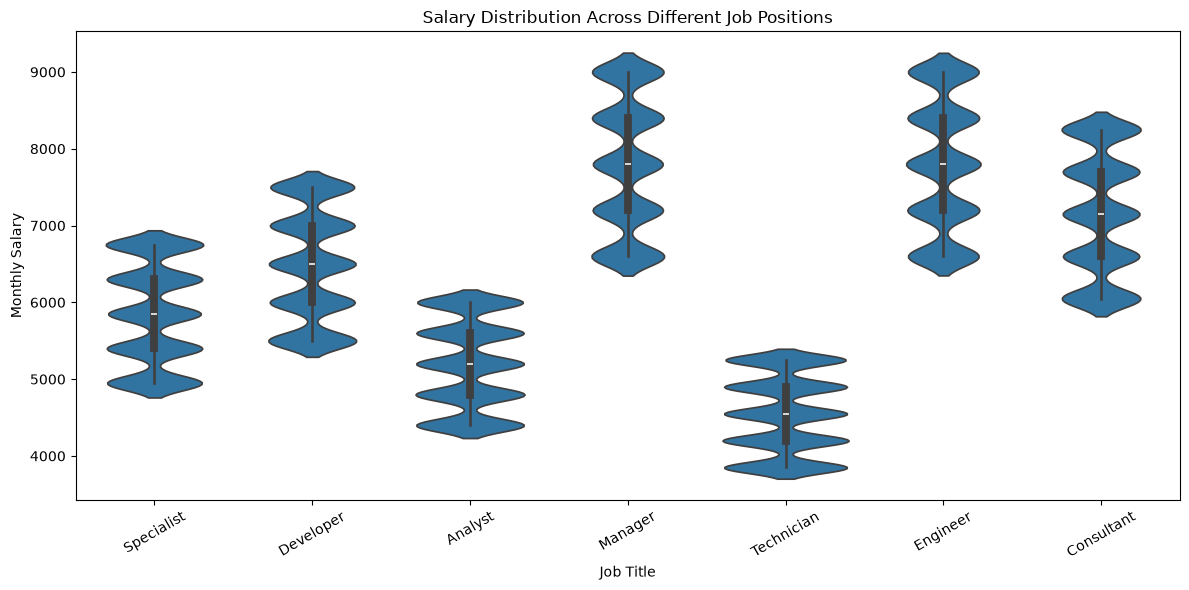

In [13]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Job_Title",
    y="Monthly_Salary",
    inner="box"
)

plt.title("Salary Distribution Across Different Job Positions")
plt.xlabel("Job Title")
plt.ylabel("Monthly Salary")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [14]:
salary_skewness = df["Monthly_Salary"].skew()

print("Salary Skewness:", round(salary_skewness, 4))

Salary Skewness: 0.1013


In [15]:
if salary_skewness > 1:
    print("Salary distribution is highly right-skewed.")

elif salary_skewness > 0.5:
    print("Salary distribution is moderately right-skewed.")

elif salary_skewness < -1:
    print("Salary distribution is highly left-skewed.")

elif salary_skewness < -0.5:
    print("Salary distribution is moderately left-skewed.")

else:
    print("Salary distribution is approximately symmetric.")

Salary distribution is approximately symmetric.


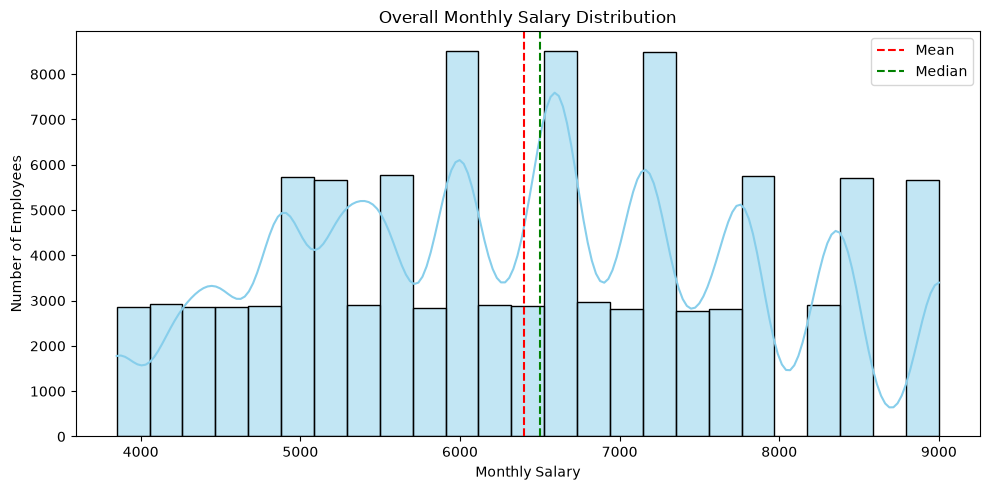

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Monthly_Salary",
    bins=25,
    kde=True,
    color="skyblue"
)

plt.axvline(
    df["Monthly_Salary"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df["Monthly_Salary"].median(),
    color="green",
    linestyle="--",
    label="Median"
)

plt.title("Overall Monthly Salary Distribution")
plt.xlabel("Monthly Salary")
plt.ylabel("Number of Employees")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
job_mean_salary = (
    df.groupby("Job_Title")["Monthly_Salary"]
    .mean()
    .sort_values(ascending=False)
)

print(job_mean_salary.round(2))

Job_Title
Engineer      7799.32
Manager       7798.32
Consultant    7152.09
Developer     6490.14
Specialist    5855.34
Analyst       5195.82
Technician    4545.15
Name: Monthly_Salary, dtype: float64


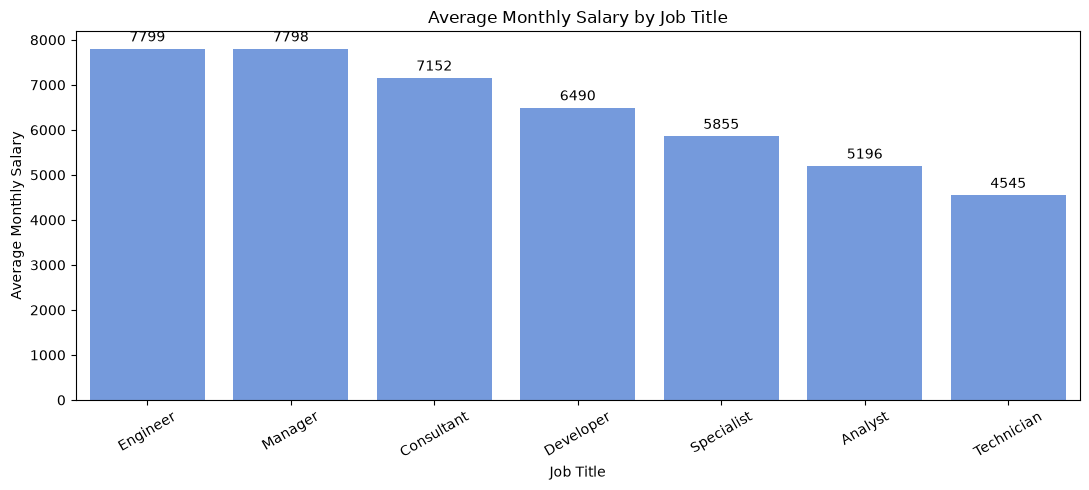

In [18]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    x=job_mean_salary.index,
    y=job_mean_salary.values,
    color="cornflowerblue"
)

plt.title("Average Monthly Salary by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Average Monthly Salary")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [19]:
gender_salary_stats = df.groupby("Gender")[
    "Monthly_Salary"
].agg(["count", "mean", "median"])

gender_salary_stats.round(2)

,count,mean,median
Gender,,,
Female,48001,6404.99,6500.0
Male,48031,6400.48,6500.0
Other,3968,6414.77,6500.0


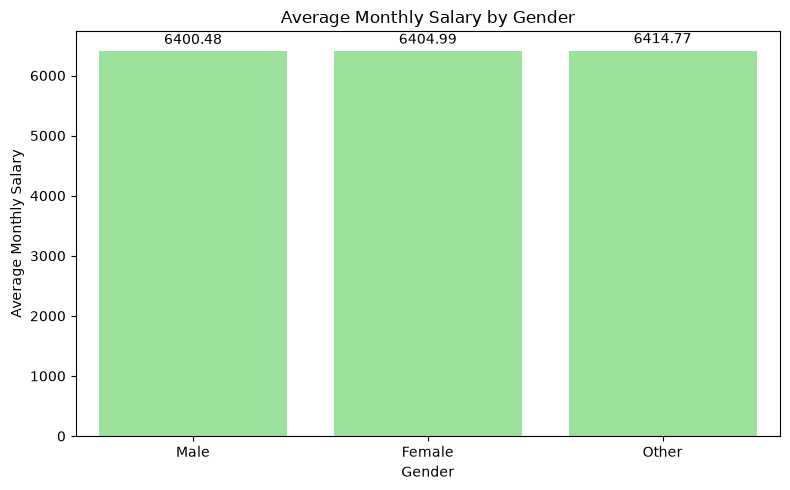

In [20]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="Gender",
    y="Monthly_Salary",
    estimator="mean",
    errorbar=None,
    color="lightgreen"
)

plt.title("Average Monthly Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Monthly Salary")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [21]:
job_gender_salary = df.pivot_table(
    index="Job_Title",
    columns="Gender",
    values="Monthly_Salary",
    aggfunc="mean"
)

job_gender_salary = job_gender_salary.round(2)

job_gender_salary

Gender,Female,Male,Other
Job_Title,,,
Analyst,5193.07,5198.39,5197.18
Consultant,7138.44,7161.54,7198.47
Developer,6491.90,6491.20,6453.15
Engineer,7795.74,7801.25,7818.97
Manager,7805.06,7791.12,7804.37
Specialist,5848.83,5861.77,5855.64
Technician,4545.91,4544.95,4538.51


In [22]:
gender_columns = [
    "Female",
    "Male",
    "Other"
]

job_gender_salary["Highest_Average"] = (
    job_gender_salary[gender_columns].max(axis=1)
)

job_gender_salary["Lowest_Average"] = (
    job_gender_salary[gender_columns].min(axis=1)
)

job_gender_salary["Salary_Gap"] = (
    job_gender_salary["Highest_Average"]
    - job_gender_salary["Lowest_Average"]
)

job_gender_salary["Gap_Percentage"] = (
    job_gender_salary["Salary_Gap"]
    / job_gender_salary["Highest_Average"]
) * 100

pay_gap_table = job_gender_salary.sort_values(
    by="Gap_Percentage",
    ascending=False
)

pay_gap_table.round(2)

Gender,Female,Male,Other,Highest_Average,Lowest_Average,Salary_Gap,Gap_Percentage
Job_Title,,,,,,,
Consultant,7138.44,7161.54,7198.47,7198.47,7138.44,60.03,0.83
Developer,6491.90,6491.20,6453.15,6491.90,6453.15,38.75,0.60
Engineer,7795.74,7801.25,7818.97,7818.97,7795.74,23.23,0.30
Specialist,5848.83,5861.77,5855.64,5861.77,5848.83,12.94,0.22
Manager,7805.06,7791.12,7804.37,7805.06,7791.12,13.94,0.18
Technician,4545.91,4544.95,4538.51,4545.91,4538.51,7.40,0.16
Analyst,5193.07,5198.39,5197.18,5198.39,5193.07,5.32,0.10


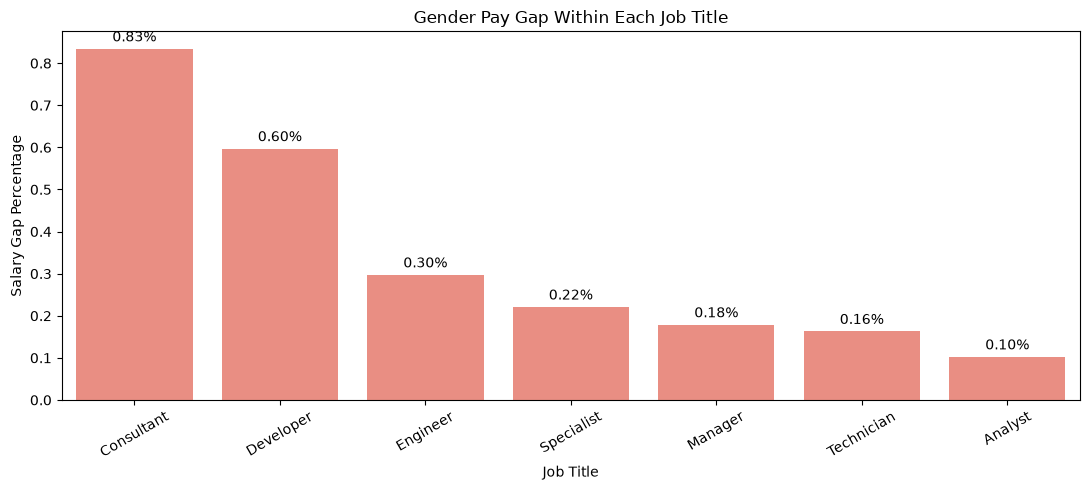

In [23]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=pay_gap_table.reset_index(),
    x="Job_Title",
    y="Gap_Percentage",
    color="salmon"
)

plt.title("Gender Pay Gap Within Each Job Title")
plt.xlabel("Job Title")
plt.ylabel("Salary Gap Percentage")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

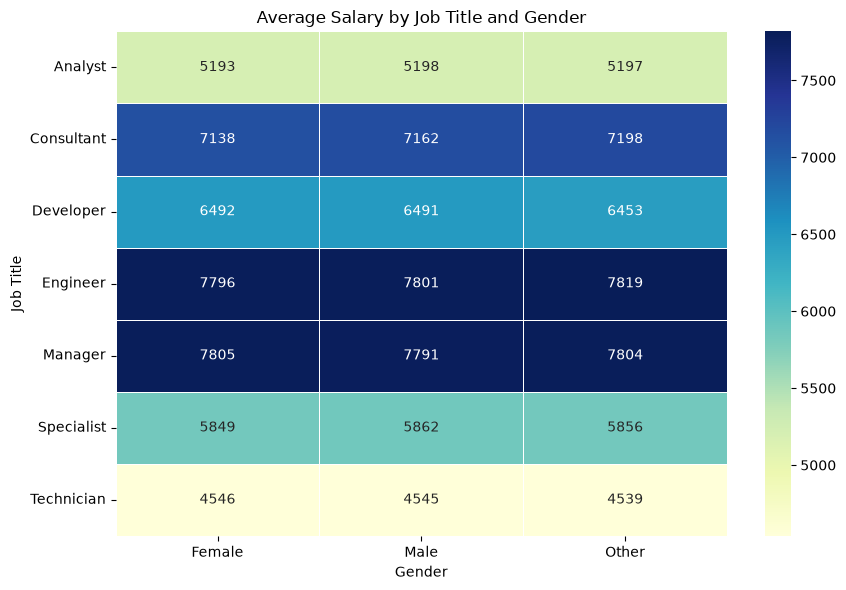

In [24]:
heatmap_data = job_gender_salary[
    ["Female", "Male", "Other"]
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average Salary by Job Title and Gender")
plt.xlabel("Gender")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

In [25]:
department_salary = (
    df.groupby("Department")["Monthly_Salary"]
    .mean()
    .sort_values(ascending=False)
)

print(department_salary.round(2))

Department
Engineering         6417.25
IT                  6414.60
Sales               6413.15
Operations          6412.31
Customer Support    6403.88
HR                  6400.36
Finance             6398.58
Legal               6391.28
Marketing           6377.86
Name: Monthly_Salary, dtype: float64


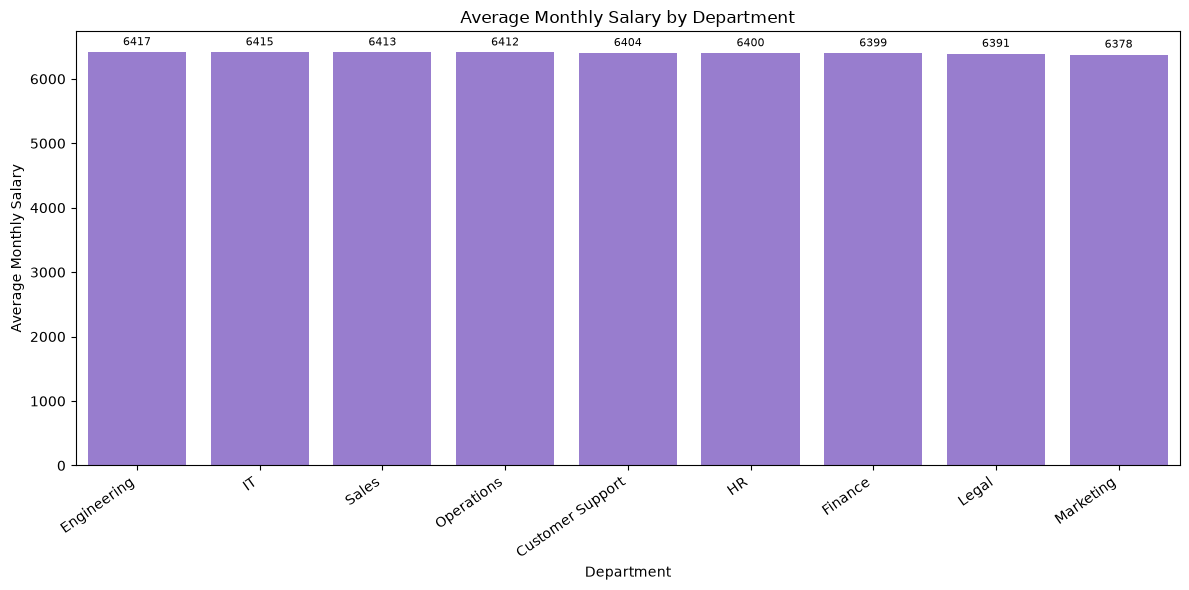

In [26]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=department_salary.index,
    y=department_salary.values,
    color="mediumpurple"
)

plt.title("Average Monthly Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Salary")
plt.xticks(rotation=35, ha="right")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [27]:
highest_paid_job = job_mean_salary.idxmax()
highest_job_salary = job_mean_salary.max()

lowest_paid_job = job_mean_salary.idxmin()
lowest_job_salary = job_mean_salary.min()

highest_gap_job = pay_gap_table[
    "Gap_Percentage"
].idxmax()

highest_gap_percentage = pay_gap_table[
    "Gap_Percentage"
].max()

print("Salary skewness:", round(salary_skewness, 4))

print(
    "Highest-paid job:",
    highest_paid_job,
    "-",
    round(highest_job_salary, 2)
)

print(
    "Lowest-paid job:",
    lowest_paid_job,
    "-",
    round(lowest_job_salary, 2)
)

print(
    "Highest pay-gap job:",
    highest_gap_job,
    "-",
    round(highest_gap_percentage, 2),
    "%"
)

Salary skewness: 0.1013
Highest-paid job: Engineer - 7799.32
Lowest-paid job: Technician - 4545.15
Highest pay-gap job: Consultant - 0.83 %
